<a href="https://colab.research.google.com/github/Qencels/ml_course_practice/blob/main/homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UCI Bank Marketing Dataset
#### Поставлена задача классификации, а именно: необходимо определить, откроет ли клиент срочный депозит (bank term deposit)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import kagglehub

#### 1. Получение данных

In [ ]:
path = kagglehub.dataset_download("adityamhaske/bank-marketing-dataset") + "/bank-full.csv"
data_raw = pd.read_csv(path, delimiter = ';')

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.


In [ ]:
data_raw.shape

(45211, 17)

In [ ]:
data_raw

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [ ]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


#### 2. Описание и обработка признаков


*   age - возраст (числовой)
*   job - род занятий (категориальный)
*   marital - семейное положение (категориальный)
*   education - образование (категориальный)
*   default - наличие задолженности по кредиту (бинарный)
*   balance - среднегодовой баланс (числовой)
*   housing - наличие ипотеки (бинарный)
*   loan - наличие личного кредита (бинарный)
*   contact - тип связи с клиентом (категориальный)
*   day - день контакта (числовой)
*   month - месяц контакта (категориальный)
*   duration - время контакта (числовой)
*   campaign - количество контактов с клиентом за кампанию (числовой)
*   pdays - количество дней, прошедших после последнего контакта с клиентом из предыдущей кампании (числовой, -1, если контакта не было)
*   previous - количество контактов, выполненных до этой кампании для этого клиента (числовой)
*   poutcome - результат предыдущей маркетинговой кампании для клиента (категориальный)
*   y - открыл ли клиент срочный депозит? (бинарный)

Заметим, что duration серьёзно влияет на результат классификации, при duration = 0, очевидно, что депозит открыт не будет, заранее длительность звонка неизвестна, так что это утечка данных. Также, нужно проверить корреляцию с целевой переменной дня и месяца контакта, вероятно, их можно будет не учитывать при последующем анализе.



In [ ]:
data_raw.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
# Заметим, что в pdays доминирует значение -1, хотя он считается числовым признаком. Возможно, стоит его бинаризовать.

total_records = len(data_raw)
count_minus_one = (data_raw['pdays'] == -1).sum()
percentage_minus_one = (count_minus_one / total_records) * 100
print(f"Процент записей с pdays = -1: {percentage_minus_one:.2f}%")

Процент записей с pdays = -1: 81.74%


In [ ]:
# Значение -1 будет некорректно учтено моделью, создадим из pdays маркер

data_raw['pdays_contacted'] = np.where(
    data_raw['pdays'] == -1,
    0,  # Не было предыдущего контакта
    1   # Был предыдущий контакт
)

data_raw.drop(columns=['pdays'], inplace=True)
data_raw.shape

(45211, 17)

In [ ]:
data_raw.describe(include=['object'])

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


Заметим, что default практически всегда равен "no", примерно в 98.2% случаев, что говорит о его низкой вариативности.

In [ ]:
data_temp = data_raw.copy()
data_temp['y_encoded'] = data_temp['y'].map({'yes': 1, 'no': 0})
data_temp = data_temp[data_temp['default'] != 'unknown']
data_temp['default_encoded'] = data_temp['default'].map({'yes': 1, 'no': 0})
correlation = data_temp['default_encoded'].corr(data_temp['y_encoded'])
print(f"Корреляция между 'default' и 'y' (после кодирования): {correlation:.4f}")

Корреляция между 'default' и 'y' (после кодирования): -0.0224


Также, default не обладает сильной корреляционной связью с целевой переменной, можно исключить его из анализа.

In [ ]:
data_raw.drop(columns=['default', 'duration'], inplace=True)
data_raw.shape

(45211, 15)

In [ ]:
data_raw.isnull().sum()

,0
age,0
job,0
marital,0
education,0
balance,0
housing,0
loan,0
contact,0
day,0
month,0


In [ ]:
# в нашем случае, пропущенные значения были закодированы в датасете как unknown
categorical_cols = data_raw.select_dtypes(include=['object', 'category']).columns
unknown_counts = {}

for col in categorical_cols:
    count = (data_raw[col] == 'unknown').sum()

    if count > 0:
        total_rows = len(data_raw)
        percentage = (count / total_rows) * 100
        unknown_counts[col] = {
            'Count': count,
            'Percentage': f"{percentage:.2f}%"
        }

result_df = pd.DataFrame.from_dict(unknown_counts, orient='index')
result_df.index.name = 'Feature'
print("Количество и доля 'unknown' по категориальным признакам:")
print(result_df)


Количество и доля 'unknown' по категориальным признакам:
           Count Percentage
Feature                    
job          288      0.64%
education   1857      4.11%
contact    13020     28.80%
poutcome   36959     81.75%


In [ ]:
# обработаем категориальные и бинарные признаки
object_cols = data_raw.select_dtypes(include=['object']).columns
for col in object_cols:
    data_raw[col] = data_raw[col].astype('category')

data_raw['y'] = data_raw['y'].map({'yes': 1, 'no': 0})
data_raw['housing'] = data_raw['housing'].map({'yes': 1, 'no': 0})
data_raw['loan'] = data_raw['loan'].map({'yes': 1, 'no': 0})

data_raw['y'] = data_raw['y'].astype(int)
data_raw['housing'] = data_raw['housing'].astype(int)
data_raw['loan'] = data_raw['loan'].astype(int)

print(data_raw[object_cols].dtypes)

job          category
marital      category
education    category
housing         int64
loan            int64
contact      category
month        category
poutcome     category
y               int64
dtype: object


In [ ]:
cols = ['job', 'education', 'contact', 'poutcome']
for col in cols:
    print(data_raw[col].cat.categories)


Index(['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management',
       'retired', 'self-employed', 'services', 'student', 'technician',
       'unemployed', 'unknown'],
      dtype='object')
Index(['primary', 'secondary', 'tertiary', 'unknown'], dtype='object')
Index(['cellular', 'telephone', 'unknown'], dtype='object')
Index(['failure', 'other', 'success', 'unknown'], dtype='object')


Видно, что poutcome и contact имеют большой процент unknown значений. Также, в job и education есть их небольшое количество. В уровне образования это значение может быть интерпретировано как его отсутствие или незафиксированный уровень, тогда как в роде занятий - именно отсутствие информации о клиенте, поскольку данный признак предполагает такие категории, как безработный, самозанятый и другие. Unknown contact следует рассматривать как отдельную категорию, потому что её доля составляет 28.8%, что делает невозможным замену средними значениями без серьёзных искажений. Poutcome, возможно, стоило бы исключить из-за высокой неопределённости, но информация об участии в прошлых кампаниях должна сильно влиять на принимаемое клиентом решение.

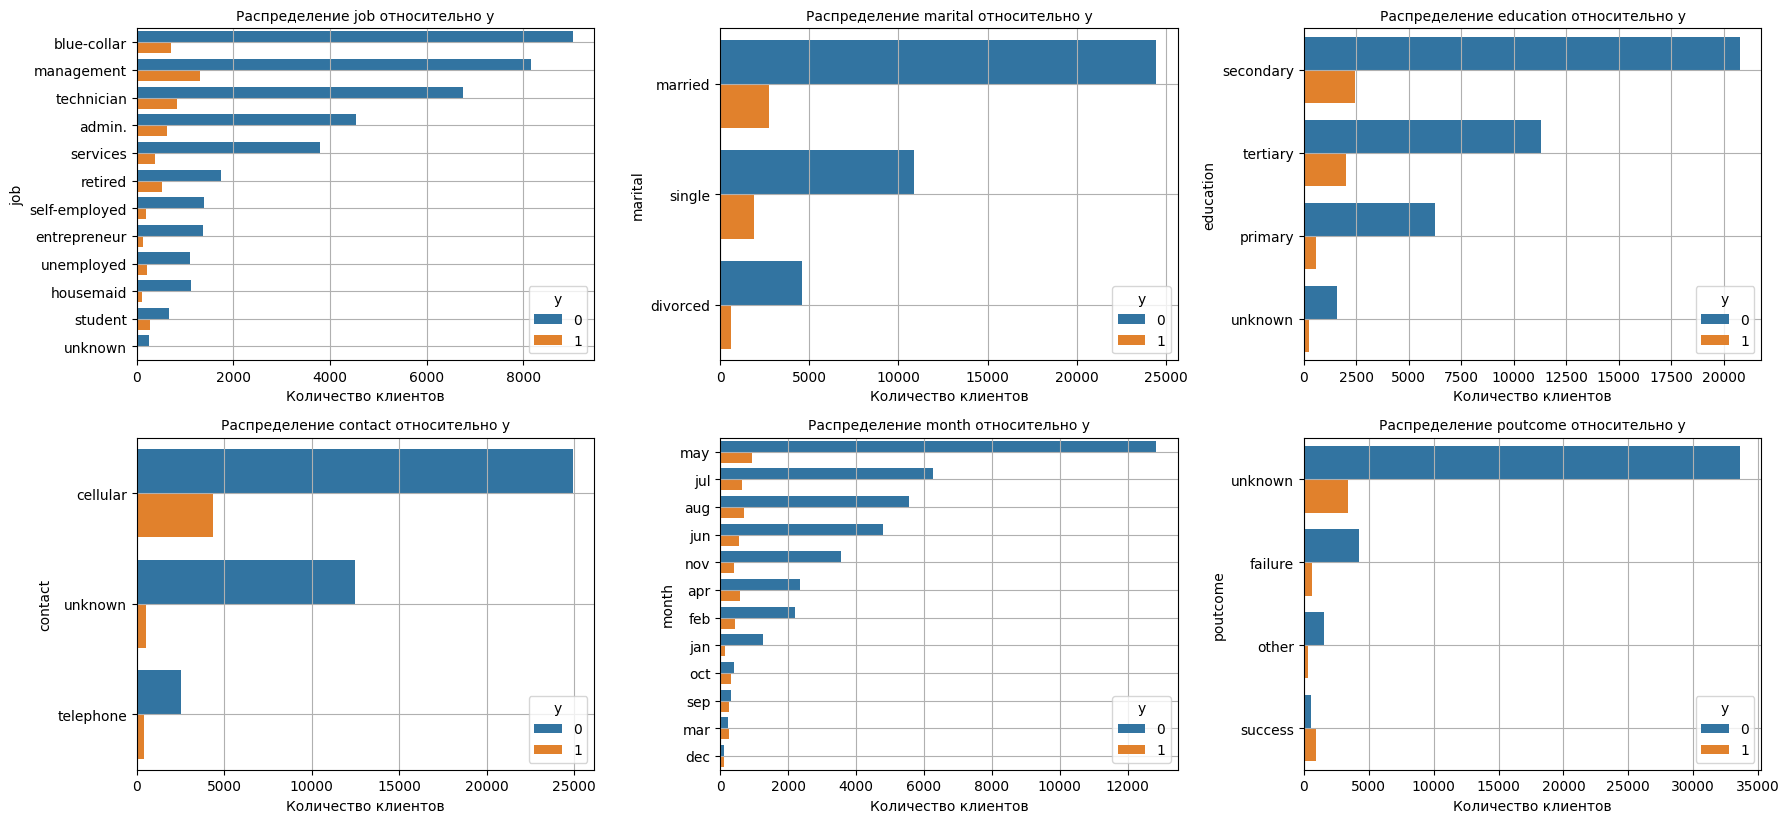

job
               y=1 (%)
job                   
student          28.68
retired          22.79
unemployed       15.50
management       13.76
admin.           12.20
self-employed    11.84
unknown          11.81
technician       11.06
services          8.88
housemaid         8.79
entrepreneur      8.27
blue-collar       7.27
marital
          y=1 (%)
marital          
single      14.95
divorced    11.95
married     10.12
education
           y=1 (%)
education         
tertiary     15.01
unknown      13.57
secondary    10.56
primary       8.63
contact
           y=1 (%)
contact           
cellular     14.92
telephone    13.42
unknown       4.07
month
       y=1 (%)
month         
mar      51.99
dec      46.73
sep      46.46
oct      43.77
apr      19.68
feb      16.65
aug      11.01
jun      10.22
nov      10.15
jan      10.12
jul       9.09
may       6.72
poutcome
          y=1 (%)
poutcome         
success     64.73
other       16.68
failure     12.61
unknown      9.16


/tmp/ipython-input-973613014.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  response_rate = data_raw.groupby(col)['y'].mean().sort_values(ascending=False)
/tmp/ipython-input-973613014.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  response_rate = data_raw.groupby(col)['y'].mean().sort_values(ascending=False)
/tmp/ipython-input-973613014.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  response_rate = data

In [ ]:
# Визуализация

cat_cols = data_raw.select_dtypes(include=['category']).columns.tolist()
if 'y' in cat_cols:
    cat_cols.remove('y')

plt.figure(figsize=(18, 12))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 3, i + 1)

    sns.countplot(y=col, hue='y', data=data_raw, order=data_raw[col].value_counts().index)
    plt.title(f'Распределение {col} относительно y', fontsize=10)
    plt.ylabel(col)
    plt.xlabel('Количество клиентов')
    plt.tight_layout()
    plt.grid()
plt.show()

for col in cat_cols:
    response_rate = data_raw.groupby(col)['y'].mean().sort_values(ascending=False)
    response_rate_percent = (response_rate * 100).round(2)
    result_df = pd.DataFrame(response_rate_percent).rename(columns={'y': 'y=1 (%)'})
    print(f"{col}")
    print(result_df)

Как можно видеть, успех в предыдущей рекламной кампании (poutcome - success) сильно влияет на результат. Также, имеет место сезонность кампании, наиболее удачные месяцы - март, декабрь, сентябрь и октябрь. Студенты, пенсионеры и безработные - чаще соглашаются открыть депозит, как и одинокие, разведённые, а также люди с высшим образованием (стоит учесть долю 13.57% с незафиксированным уровнем образования). Наличие кредита или ипотеки снижают вероятность успеха, как и не установленный тип связи с клиентом.

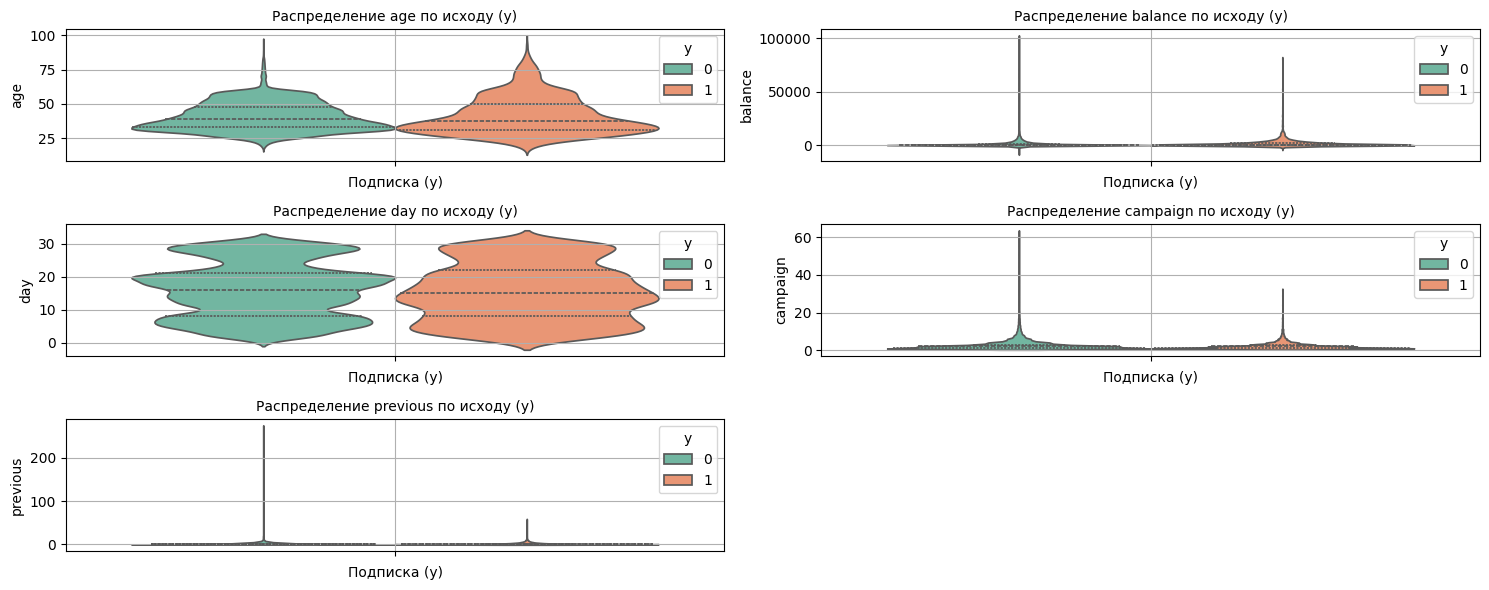

In [ ]:
plt.figure(figsize=(15, 6))
numerical_features = data_raw.select_dtypes(include=['number']).columns.tolist()
numerical_features.remove('y')
numerical_features.remove('pdays_contacted')
numerical_features.remove('loan')
numerical_features.remove('housing')

for i, col in enumerate(numerical_features):
    plt.subplot(3, 2, i + 1)

    sns.violinplot(hue='y', y=col, data=data_raw, palette='Set2', inner='quartile', ax=plt.gca())
    plt.title(f'Распределение {col} по исходу (y)', fontsize=10)
    plt.xlabel('Подписка (y)')
    plt.ylabel(col)
    plt.grid()

plt.tight_layout()
plt.show()

                   count         mean          std     min   25%    50%     75%       max
age              45211.0    40.936210    10.618762    18.0  33.0   39.0    48.0      95.0
balance          45211.0  1362.272058  3044.765829 -8019.0  72.0  448.0  1428.0  102127.0
housing          45211.0     0.555838     0.496878     0.0   0.0    1.0     1.0       1.0
loan             45211.0     0.160226     0.366820     0.0   0.0    0.0     0.0       1.0
day              45211.0    15.806419     8.322476     1.0   8.0   16.0    21.0      31.0
campaign         45211.0     2.763841     3.098021     1.0   1.0    2.0     3.0      63.0
previous         45211.0     0.580323     2.303441     0.0   0.0    0.0     0.0     275.0
y                45211.0     0.116985     0.321406     0.0   0.0    0.0     0.0       1.0
pdays_contacted  45211.0     0.182633     0.386369     0.0   0.0    0.0     0.0       1.0
           count unique          top   freq
job        45211     12  blue-collar   9732
marital    4

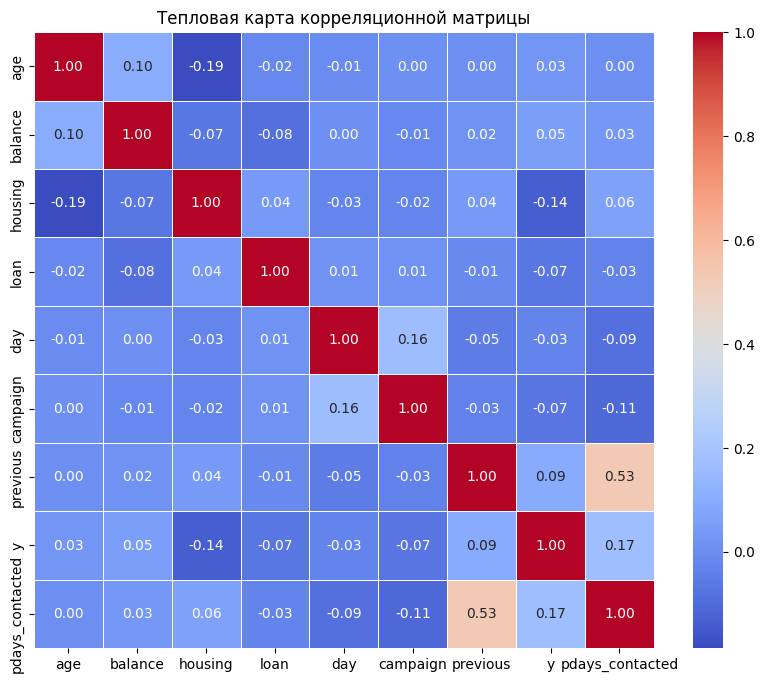

y                  1.000000
pdays_contacted    0.167263
previous           0.093236
balance            0.052838
age                0.025155
day               -0.028348
loan              -0.068185
campaign          -0.073172
housing           -0.139173


In [ ]:
num_cols = data_raw.select_dtypes(include=['number']).columns

print(data_raw[num_cols].describe().T.to_string())
print(data_raw.describe(include=['category']).T.to_string())

correlation_matrix = data_raw[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Тепловая карта корреляционной матрицы')
plt.show()

print(correlation_matrix['y'].sort_values(ascending=False).to_string())

Признак balance имеет явную скошенность, как и campaign, previous. Наличие выбросов подтверждается скрипичными диаграммами. Корреляционная матрица свидетельствует о наличии связи между pdays_contacted и previous, что и ожидалось. Опять же, наличие прошлого контакта (pdays_contacted=1) повышает вероятность успеха. Присутствует незначительная связь с целевой переменной и у previous, campaign. Первый признак укладывается в общую логику с наличием прошлых контактов, тогда как campaign негативно влияет на вероятность успеха. Кажется, что большое количество звонков раздражает клиентов.

In [ ]:
# обработка выбросов

data_processed = data_raw.copy()

features_to_check = ['balance', 'campaign', 'previous']
total_records = len(data_processed)

for col in features_to_check:
    data_series_valid = data_processed[col].dropna()

    lower_percentile = data_series_valid.quantile(0.05)
    upper_percentile = data_series_valid.quantile(0.95)

    outliers_lower_count = len(data_processed[data_processed[col] < lower_percentile])
    outliers_upper_count = len(data_processed[data_processed[col] > upper_percentile])

    outliers_count = outliers_lower_count + outliers_upper_count
    outliers_percentage = (outliers_count / total_records) * 100

    data_processed[col] = np.where(
        data_processed[col] > upper_percentile,
        upper_percentile,
        data_processed[col]
    )

    data_processed[col] = np.where(
        data_processed[col] < lower_percentile,
        lower_percentile,
        data_processed[col]
    )

    print(f"\nПризнак '{col}'")
    print(f"Нижняя граница (0.5%): {lower_percentile:.2f}")
    print(f"Верхняя граница (99.5%): {upper_percentile:.2f}")
    print(f"Количество нижних выбросов: {outliers_lower_count}")
    print(f"Количество верхних выбросов: {outliers_upper_count}")
    print(f"Процент выбросов: {outliers_percentage:.2f}%")

print(data_processed[features_to_check].describe().T.to_string())



Признак 'balance'
Нижняя граница (0.5%): -172.00
Верхняя граница (99.5%): 5768.00
Количество нижних выбросов: 2259
Количество верхних выбросов: 2260
Процент выбросов: 10.00%

Признак 'campaign'
Нижняя граница (0.5%): 1.00
Верхняя граница (99.5%): 8.00
Количество нижних выбросов: 0
Количество верхних выбросов: 1789
Процент выбросов: 3.96%

Признак 'previous'
Нижняя граница (0.5%): 0.00
Верхняя граница (99.5%): 3.00
Количество нижних выбросов: 0
Количество верхних выбросов: 2237
Процент выбросов: 4.95%
            count         mean          std    min   25%    50%     75%     max
balance   45211.0  1116.990843  1581.303636 -172.0  72.0  448.0  1428.0  5768.0
campaign  45211.0     2.511513     1.905038    1.0   1.0    2.0     3.0     8.0
previous  45211.0     0.378691     0.881417    0.0   0.0    0.0     0.0     3.0


#### Разбиение на обучающую и тестовую выборки (3:1)
Наконец, заметим, что признак day имеет слабую прогностическую ценность, слабую корреляционную связь и отсутствие выбросов, можем исключить его из анализа.

In [ ]:
X = data_processed.drop(['y', 'day'], axis=1)
y = data_processed['y']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.75, random_state = 42)

N_train, _ = X_train.shape
N_test,  _ = X_test.shape

N_train, N_test

(11302, 33909)

In [ ]:
# Обработка категориальных признаков one-hot энкодером

all_categorical_features = data_processed.select_dtypes(include=['object', 'category']).columns.tolist()
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(drop='if_binary', sparse_output=False)
enc.fit(X_train[all_categorical_features])

dummies = pd.DataFrame(enc.transform(X_train[all_categorical_features]),
                       columns=enc.get_feature_names_out(), index=X_train.index)

X_train = pd.concat((X_train, dummies), axis=1).drop(all_categorical_features, axis=1)

dummies_test = pd.DataFrame(
    enc.transform(X_test[all_categorical_features]),
    columns=enc.get_feature_names_out(),
    index=X_test.index
)

X_test = pd.concat([X_test.drop(all_categorical_features, axis=1), dummies_test], axis=1)

In [ ]:
# Нормализация (стандартизация). Необходима из-за разности диапазонов (масштабов) числовых признаков,
# из-за чего модель может придавать непропорционально большой вес более "широкому" признаку, несмотря на его прогностическую ценность.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test[:] = scaler.transform(X_test)

/tmp/ipython-input-261410651.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.10173806  0.56055972 -1.5209476  ... -0.38557997 -1.71017554
  0.56055972]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_test[:] = scaler.transform(X_test)
/tmp/ipython-input-261410651.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.89424914 -1.11825659  0.89424914 ...  0.89424914  0.89424914
  0.89424914]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_test[:] = scaler.transform(X_test)
/tmp/ipython-input-261410651.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.43163942 -0.43163942 -0.43163942 ... -0.43163942 -0.43163942
 -0.43163942]' has dtype incompatible with int64, please explici

#### Обучение и оценка модели
Классы в датасете сильно несбалансированны, а некоторые признаки, несмотря на всю предварительную подготовку - имеют большое количество выбросов. Метод k-ближайших соседей очень чувствителен к масштабированию признаков, явно не может назначать разный вес, и более склонен к доминирующему классу. В качестве альтернативы используем метод градиентного бустинга: построим обе модели, вычислим ошибки и подберём гиперпараметры.

RMSE: 0.28779176905657144
R2: 0.19806589805577868

Точность (Accuracy): 0.8833642985638032
Точность (Precision): 0.5031446540880503
Полнота (Recall): 0.22188603126575895
F1-мера (F1-score): 0.3079615048118985
Матрица ошибок (Confusion Matrix):


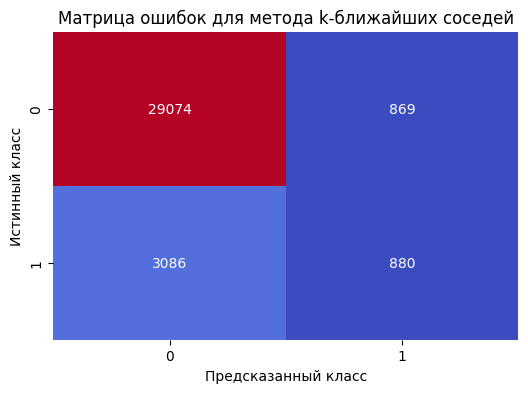

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

RMSE_train = mean_squared_error(y_train, y_train_predict)**.5
RMSE_test  = mean_squared_error(y_test,  y_test_predict)**.5
R2_train = r2_score(y_train, y_train_predict)
R2_test  = r2_score(y_test,  y_test_predict)

print(f'RMSE: {RMSE_test}\nR2: {R2_test}\n')

# accuracy, confusion_matrix, precision, recall и f1 можно вычислить с помощью встроенных функций sklearn

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print(f"Точность (Accuracy): {accuracy_knn}")
print(f"Точность (Precision): {precision_knn}")
print(f"Полнота (Recall): {recall_knn}")
print(f"F1-мера (F1-score): {f1_knn}")
print("Матрица ошибок (Confusion Matrix):")

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='coolwarm', cbar=False)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок для метода k-ближайших соседей')
plt.show()


Общая высокая точность связана с высокой несбалансированностью классов, хотя модель и классифицирует 89% случаев правильно, большинство из них выпадает на доминирующий класс. F1-мера и полнота говорят о том, что подавляющее большинство потенциальных клиентов пропущено.

Точность (Accuracy): 0.8919460910082869
Точность (Precision): 0.6130239520958084
Полнота (Recall): 0.2065052950075643
F1-мера (F1-score): 0.3089400226329687
Матрица ошибок (Confusion Matrix):


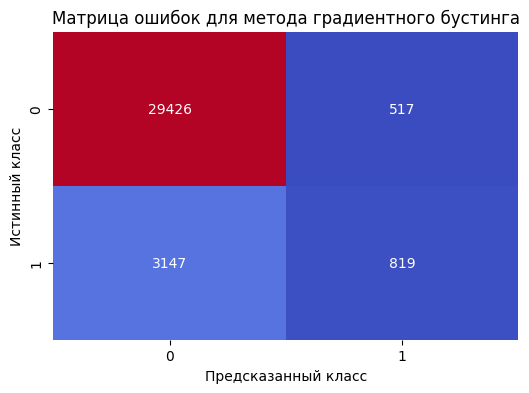

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(random_state=42)
gbm.fit(X_train, y_train)
y_pred_gbm = gbm.predict(X_test)

accuracy_gbm = accuracy_score(y_test, y_pred_gbm)
conf_matrix_gbm = confusion_matrix(y_test, y_pred_gbm)
precision_gbm = precision_score(y_test, y_pred_gbm)
recall_gbm = recall_score(y_test, y_pred_gbm)
f1_gbm = f1_score(y_test, y_pred_gbm)

print(f"Точность (Accuracy): {accuracy_gbm}")
print(f"Точность (Precision): {precision_gbm}")
print(f"Полнота (Recall): {recall_gbm}")
print(f"F1-мера (F1-score): {f1_gbm}")
print("Матрица ошибок (Confusion Matrix):")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_gbm, annot=True, fmt='d', cmap='coolwarm', cbar=False)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок для метода градиентного бустинга')
plt.show()

Видим аналогичные результаты. Проведём подбор гиперпараметров.

Лучший результат (F1-macro): 0.8611
Оптимальное k: 15


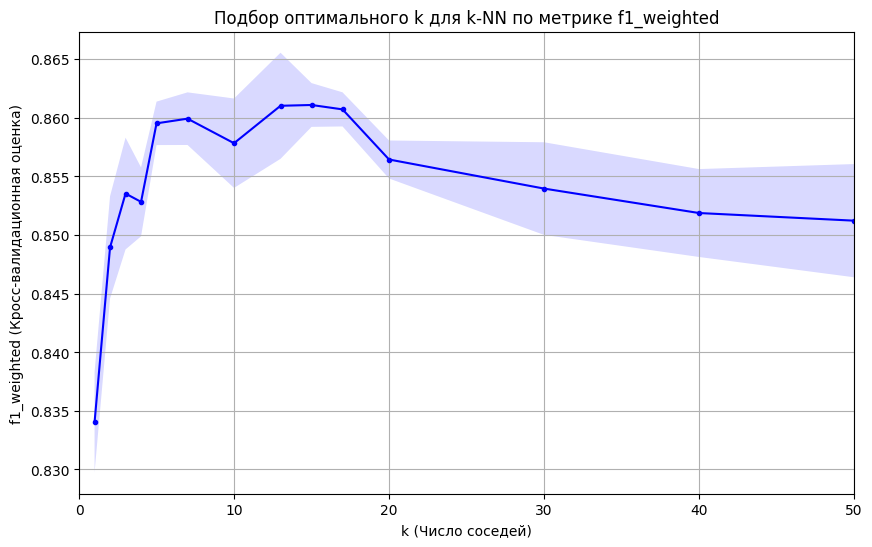

In [ ]:
from sklearn.model_selection import GridSearchCV

k_arr = np.array([1, 2, 3, 4, 5, 7, 10, 13, 15, 17, 20, 30, 40, 50])

params = {
    'n_neighbors': k_arr,
}

scorer = 'f1_weighted'
model = GridSearchCV(knn, params, scoring=scorer, cv=5)
model.fit(X_train, y_train)

print(f"Лучший результат (F1-macro): {model.best_score_:.4f}")
print(f"Оптимальное k: {model.best_params_['n_neighbors']}")

score_arr = model.cv_results_[f'mean_test_score']
std_arr = model.cv_results_['std_test_score']

plt.figure(figsize=(10, 6))
plt.plot(k_arr, score_arr, 'b.-')
plt.fill_between(k_arr, score_arr - std_arr, score_arr + std_arr, alpha=0.15, facecolor='blue')
plt.grid(True)
plt.xlabel('k (Число соседей)')
plt.ylabel(f'{scorer} (Кросс-валидационная оценка)')
plt.title(f'Подбор оптимального k для k-NN по метрике {scorer}')
plt.xlim([0, max(k_arr)])
plt.show()

In [ ]:
# для градиентного бустинга

from sklearn.model_selection import RandomizedSearchCV

hgbc = HistGradientBoostingClassifier(class_weight='balanced', # учитываем редкость класса y=1
                                     random_state=42)

param_distributions = {
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 15),
    'max_iter': randint(100, 500),
    'min_samples_leaf': randint(20, 100),
    'l2_regularization': uniform(0.0, 1.0)
}

scorer = make_scorer(f1_score, average='macro')

random_search = RandomizedSearchCV(
    estimator=hgbc,
    param_distributions=param_distributions,
    n_iter=100,
    scoring=scorer,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

print("Лучшие гиперпараметры:", random_search.best_params_)
print("Лучший результат (F1-macro) на кросс-валидации:", random_search.best_score_)

best_hgbc = random_search.best_estimator_
Y_pred_proba = best_hgbc.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.01, 0.99, 100)
best_f1_score = 0
optimal_threshold = 0.5

for threshold in thresholds:
    Y_pred_threshold = (Y_pred_proba >= threshold).astype(int)
    # Здесь используется взвешенная F1-score, можно выбрать другую метрику
    current_f1 = f1_score(y_test, Y_pred_threshold, average='macro')

    if current_f1 > best_f1_score:
        best_f1_score = current_f1
        optimal_threshold = threshold

print(f"Оптимальный порог: {optimal_threshold:.4f}")
print(f"Лучший F1-score (с оптимальным порогом): {best_f1_score:.4f}")


Fitting 3 folds for each of 100 candidates, totalling 300 fits
Лучшие гиперпараметры: {'l2_regularization': np.float64(0.5632882178455393), 'learning_rate': np.float64(0.12562495076197483), 'max_depth': 12, 'max_iter': 152, 'min_samples_leaf': 21}
Лучший результат (F1-macro) на кросс-валидации: 0.645574693046318
Оптимальный порог: 0.6732
Лучший F1-score (с оптимальным порогом): 0.6926


Наконец, обучим модели с оптимальными гиперпараметрами.

              precision    recall  f1-score   support

           0       0.93      0.93      0.93     29943
           1       0.46      0.45      0.46      3966

    accuracy                           0.87     33909
   macro avg       0.69      0.69      0.69     33909
weighted avg       0.87      0.87      0.87     33909



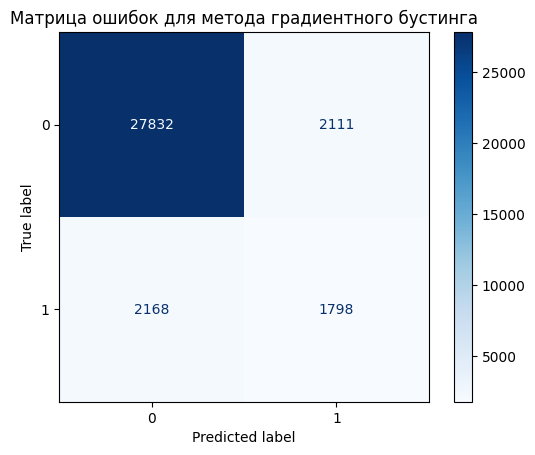

In [ ]:
optimal_params = {
    'learning_rate': 0.12562495076197483,
    'max_depth': 12,
    'max_iter': 152,
    'min_samples_leaf': 21,
    'l2_regularization': 0.5632882178455393
}

optimal_threshold = 0.6732

hgbc_final = HistGradientBoostingClassifier(
    class_weight='balanced',
    random_state=42,
    **optimal_params
)

hgbc_final.fit(X_train, y_train)
end_time = time.time()

Y_pred_proba = hgbc_final.predict_proba(X_test)[:, 1]
Y_pred_final = (Y_pred_proba >= optimal_threshold).astype(int)

print(classification_report(y_test, Y_pred_final))
ConfusionMatrixDisplay.from_predictions(y_test, Y_pred_final,
                                         cmap=plt.cm.Blues)
plt.title('Матрица ошибок для метода градиентного бустинга')
plt.show()

RMSE: 0.28779176905657144
R2: 0.19806589805577868

Точность (Accuracy): 0.8906779910938099
Точность (Precision): 0.6040160642570281
Полнота (Recall): 0.18961169944528491
F1-мера (F1-score): 0.28862022644406066
Матрица ошибок (Confusion Matrix):


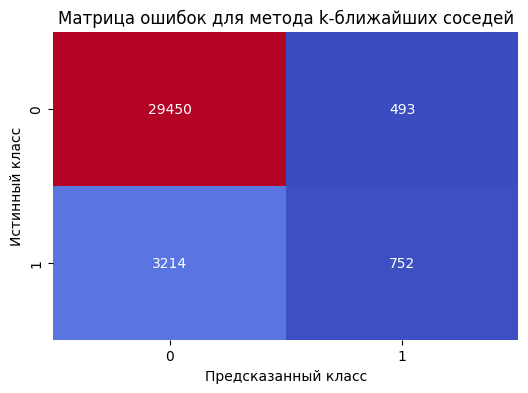

In [ ]:
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

RMSE_train = mean_squared_error(y_train, y_train_predict)**.5
RMSE_test  = mean_squared_error(y_test,  y_test_predict)**.5
R2_train = r2_score(y_train, y_train_predict)
R2_test  = r2_score(y_test,  y_test_predict)

print(f'RMSE: {RMSE_test}\nR2: {R2_test}\n')

accuracy_knn = accuracy_score(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print(f"Точность (Accuracy): {accuracy_knn}")
print(f"Точность (Precision): {precision_knn}")
print(f"Полнота (Recall): {recall_knn}")
print(f"F1-мера (F1-score): {f1_knn}")
print("Матрица ошибок (Confusion Matrix):")

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='coolwarm', cbar=False)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок для метода k-ближайших соседей')
plt.show()

#### Заключение
Построенные модели для данной задачи отлично справляются с идентификацией клиентов, которые откажутся от предложений банка, это можно использовать для минимизации расходов на кампании, направленные не на целевых клиентов (т.е. на большинство, когда вы последний раз отвечали на рекламу в телефоне?). Однако, эти модели не могут выделить достаточно сильные и явные паттерны для отличия позитивных примеров от негативных. Большую роль в этом играет сильная разбалансированность классов (и поэтому предложенная точность лучше случайного угадывания) и выбросы.

С ними лучше справляется более современный метод градиентного бустинга. А более тонкая настройка и подбор гиперпараметров значительно увеливает эффективность моделей.